In [1]:
# 다중 클래스 분류 실습
'''
데이터 : wine dataset
클래스 : 3개
데이터 로드 > 학습 모델 설정 > 학습 > 학습 결과 저장 > 성능 확인 > 신규 데이터 예측 > 결과 시각화
'''

'\n데이터 : wine dataset\n클래스 : 3개\n데이터 로드 > 학습 모델 설정 > 학습 > 학습 결과 저장 > 성능 확인 > 신규 데이터 예측 > 결과 시각화\n'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_wine          # 와인 데이터 읽어오기 
import joblib                                   # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout      # 딥러닝 레이어 구성 및 드롭아웃 
from tensorflow.keras.callbacks import EarlyStopping    # 학습 조기종료 콜백 함수
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 데이터 읽어오기(와인 데이터셋)

data = load_wine()
X = data.data
y = data.target

feature_names = data.feature_names  # 특성 이름
df = pd.DataFrame(X, columns=feature_names)

df['target'] = y
print('전체 데이터 shape : ', df.shape)
df.head()

전체 데이터 shape :  (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [5]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# one-hot 인코딩 수행 <-- 클래스 별 확률 값에서 가장 큰 값을 1로 치환하고, 나머지는 0으로 치환하여 1의 결과를 반환
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [8]:
# 모델 정의
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_test_scaled.shape[1],)))  # 첫 번째 은닉층 생성
model.add(Dropout(0.2))                                                         # 과적합 방지를 위한 드롭아웃 적용

model.add(Dense(32, activation='relu'))   # 두 번째 은닉층 추가

model.add(Dense(3, activation='softmax'))  # 출력층은 클래스 3개, 활성화 함수는 softmax

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 모델 컴파일 설정
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [10]:
# 모델 학습
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5575 - loss: 1.0152 - val_accuracy: 0.7931 - val_loss: 0.8218
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7522 - loss: 0.7940 - val_accuracy: 0.8966 - val_loss: 0.6426
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8584 - loss: 0.6489 - val_accuracy: 0.9655 - val_loss: 0.5136
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9115 - loss: 0.5127 - val_accuracy: 0.9655 - val_loss: 0.4089
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9292 - loss: 0.4660 - val_accuracy: 1.0000 - val_loss: 0.3199
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9558 - loss: 0.3464 - val_accuracy: 1.0000 - val_loss: 0.2525
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9735 - loss: 0.2970 - val_accuracy: 1.0000 - val_loss: 0.1981
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9646 - loss: 0.2484 - val_accuracy: 1.0000 - val_loss:

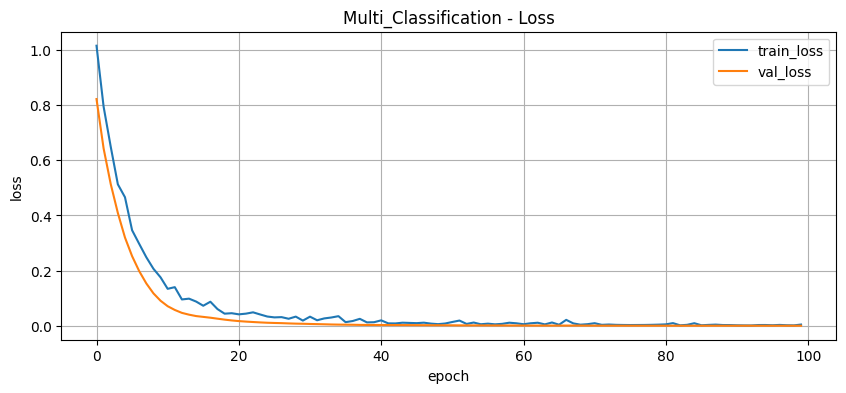

In [11]:
# 학습 loss 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Multi_Classification - Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

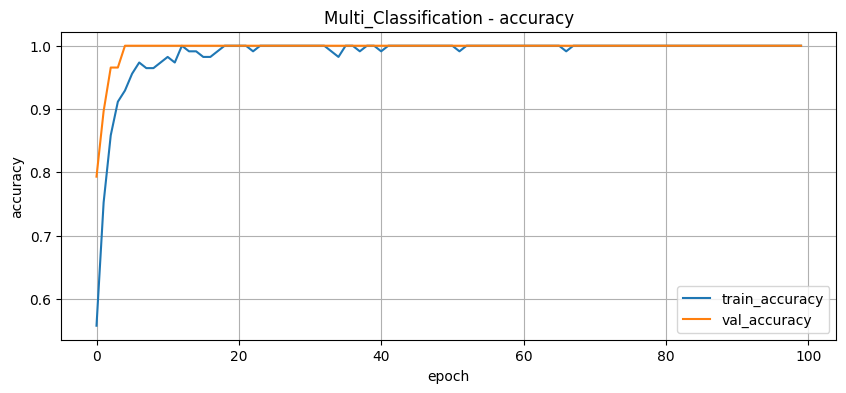

In [12]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Multi_Classification - accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# 모델 평가 : 테스트 데이터에 대해 손실과 정확도 평가

test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print('테스트 손실 : ', test_loss)
print('테스트 정확도 : ', test_acc)

# 예측확률
y_prob = model.predict(X_test_scaled)

# 가장 확률이 높은 클래스를 선택
y_pred = np.argmax(y_prob, axis=1)

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# CM 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도 : ', acc)
print('confusion matrix : \n', cm)
print('분류 리포트 : \n', classification_report(y_test, y_pred))






테스트 손실 :  0.06183536723256111
테스트 정확도 :  0.9722222089767456
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
정확도 :  0.9722222222222222
confusion matrix : 
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]
분류 리포트 : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [16]:
# 학습 결과 저장

# 모델을 파일로 저장
model.save('./results/multiclass_model.h5')

# 스케일러 저장
joblib.dump(scaler, './results/multiclass_model.pkl')

# 학습이력 데이터프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력 저장
history_df.to_csv('./results/multiclass_model.csv', index=False)

print('저장 완료')






저장 완료


In [17]:
# 저장 결과 읽어오기
loaded_model = tf.keras.models.load_model('./results/multiclass_model.h5')

loaded_scaler = joblib.load('./results/multiclass_model.pkl')

In [18]:
# 신규 데이터 예측 (추론)
new_data = X_test[:5]
new_data_scaled = loaded_scaler.transform(new_data)
new_prob = loaded_model.predict(new_data_scaled)
new_pred = np.argmax(new_prob, axis=1)

# 예측 결과 출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측클래스: {new_pred[i]}, 클래스 별 확률: {new_prob[i]}")






1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1번 샘플 - 예측클래스: 0, 클래스 별 확률: [9.9999964e-01 3.6508499e-07 4.3823970e-08]
2번 샘플 - 예측클래스: 1, 클래스 별 확률: [0.00118158 0.68391794 0.3149004 ]
3번 샘플 - 예측클래스: 0, 클래스 별 확률: [9.9997437e-01 2.2746985e-05 2.8056959e-06]
4번 샘플 - 예측클래스: 1, 클래스 별 확률: [0.39303464 0.589802   0.0171633 ]
5번 샘플 - 예측클래스: 1, 클래스 별 확률: [7.6971846e-05 9.9988830e-01 3.4663637e-05]


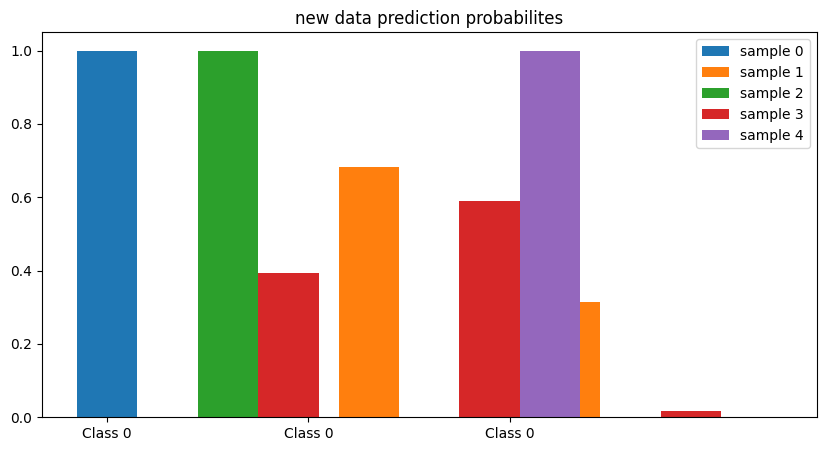

In [20]:
plt.figure(figsize=(10, 5))
for i in range(len(new_prob)):
    plt.bar(
        np.arange(3) + i*0.3,
        new_prob[i],
        width=0.3,
        label=f"sample {i}"
    )
plt.xticks([0,1,2], ['Class 0', 'Class 0', 'Class 0'])
plt.title('new data prediction probabilites')
plt.legend()
plt.show()


    